In [2]:
from dotenv import load_dotenv
from langchain_ollama import ChatOllama
import importlib.metadata as metadata
import langchain

print(f"LangChain: {langchain.__version__}")
print(f"LangGraph: {metadata.version('langgraph')}")

load_dotenv()

llm = ChatOllama(model="gpt-oss:120b-cloud", temperature=0)

print("LLM ready.")

LangChain: 1.3.0
LangGraph: 1.2.0
LLM ready.


In [3]:
from langchain_core.tools import tool

# Reusing familiar local tools from previous lessons
@tool
def get_weather(city: str) -> str:
    """Returns the current weather for a given city."""
    return f"The weather in {city} is sunny with a high of 28C."

@tool
def get_stock_price(ticker: str) -> str:
    """Returns the current stock price for a given ticker symbol.
    Use 'ZENSAR' for Zensar Technologies, 'GOOGL' for Google."""
    prices = {"ZENSAR": "527.90 INR", "GOOGL": "175.00 USD"}
    return prices.get(ticker.upper(), f"Unknown ticker: {ticker}")

TOOLS = [get_weather, get_stock_price]
print("Tools ready: get_weather, get_stock_price")

Tools ready: get_weather, get_stock_price


In [4]:
# Example 1 - Building Smallest LangGraph
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# STEP 1 - Create State
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

print("AgentState is ready!!")

AgentState is ready!!


In [5]:
# STEP 2: Define your Nodes
def call_llm(state: AgentState) -> dict:
    """One graph node: call the given LLM using current messages"""
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

In [6]:
# STEP 3: Join all nodes together using Edges
simple_graph_builder = StateGraph(AgentState)
simple_graph_builder.add_node("assistant", call_llm)

#simple_graph_builder.add_edge(first, second)
simple_graph_builder.add_edge(START, "assistant")
simple_graph_builder.add_edge("assistant", END)

simple_graph = simple_graph_builder.compile()
print('Simple graph is ready')

Simple graph is ready


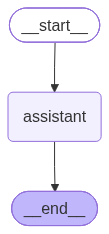

In [7]:
simple_graph

In [8]:
simple_result = simple_graph.invoke({
    "messages": [{"role": "user", "content": "Explain LangGraph in one sentence"}]
})
print(simple_result["messages"][-1].content)

LangGraph is a Python framework that lets you define, manage, and execute flexible, graph‑structured LLM workflows—connecting agents, tools, memory, and branching logic as interconnected nodes.


In [9]:
# Example 2 - Adding tools to Conditional Edge
from langgraph.prebuilt import ToolNode

llm_with_tools = llm.bind_tools(TOOLS)

In [10]:
# Node 1
def assistant(state: AgentState) -> dict:
    """Call the given LLM with tools"""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

# Node 2
def route_after_assistant(state: AgentState) -> str:
    """Route to tools only when the model procuded tool calls"""
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tools"
    return END

print("Both nodes are ready with conditional tools")

Both nodes are ready with conditional tools


In [11]:
# STEP 3: Join all nodes together using Edges
tool_graph_builder = StateGraph(AgentState)
tool_graph_builder.add_node("assistant", assistant)
tool_graph_builder.add_node("tools", ToolNode(TOOLS))

#tool_graph_builder.add_edge(first, second)
tool_graph_builder.add_edge(START, "assistant")
tool_graph_builder.add_conditional_edges(
    "assistant",
    route_after_assistant,
    {
        "tools": "tools",
        END: END
    }
)
tool_graph_builder.add_edge("tools", "assistant")
tool_graph = tool_graph_builder.compile()
print('Tool Graph is ready')

Tool Graph is ready


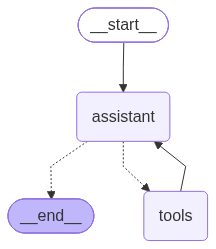

In [12]:
tool_graph

In [13]:
print(tool_graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	assistant(assistant)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> assistant;
	assistant -.-> __end__;
	assistant -.-> tools;
	tools --> assistant;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [15]:
tool_result = tool_graph.invoke({
    "messages": [{"role": "user", "content": "Explain LangGraph in one sentence"}]
})
print("Answer: ")
print(tool_result["messages"][-1].content)

Answer: 
LangGraph is a Python library that lets you design, visualize, and execute multi‑step, state‑driven LLM applications (agents) by wiring together reusable components as nodes in a directed graph.


In [17]:
tool_result = tool_graph.invoke({
    "messages": [{"role": "user", "content": "What is the current weather in Pune city?"}]
})
print("Answer: ")
print(tool_result["messages"][-1].content)

Answer: 
The current weather in Pune is sunny, with a high temperature around 28 °C.


In [18]:
print()
print("Messages captured in graph state:")
for i, msg in enumerate(tool_result["messages"], 1):
    role = msg.__class__.__name__.replace("Message", "")
    text = str(msg.content)
    text = text[:100] + "..." if len(text) > 100 else text
    print(f"[{i}] {role}: {text}")


Messages captured in graph state:
[1] Human: What is the current weather in Pune city?
[2] AI: 
[3] Tool: The weather in Pune is sunny with a high of 28C.
[4] AI: The current weather in Pune is sunny, with a high temperature around 28 °C.


In [19]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# STEP 3: Join all nodes together using Edges
graph_with_memory_builder = StateGraph(AgentState)
graph_with_memory_builder.add_node("assistant", assistant)
graph_with_memory_builder.add_node("tools", ToolNode(TOOLS))

#tool_graph_builder.add_edge(first, second)
graph_with_memory_builder.add_edge(START, "assistant")
graph_with_memory_builder.add_conditional_edges(
    "assistant",
    route_after_assistant,
    {
        "tools": "tools",
        END: END
    }
)
graph_with_memory_builder.add_edge("tools", "assistant")
tool_memory_graph = graph_with_memory_builder.compile(checkpointer=memory)
print('Tool Memory Graph is ready')

Tool Memory Graph is ready


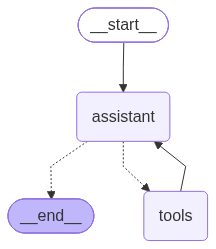

In [20]:
tool_memory_graph

In [21]:
config = {"configurable": {"thread_id": "South_indian_dishes_receipes_anand"}}

print('Turn 1')
response_1 = tool_memory_graph.invoke(
    {"messages": [{"role": "user", "content": "My name is Anand and I work with Zensar Technologies Pune"}]},
    config=config
)
print(f'Graph: {response_1['messages'][-1].content}\n')

print('Turn 2')
response_2 = tool_memory_graph.invoke(
    {"messages": [{"role": "user", "content": "What is the weather in Pune today?"}]},
    config=config
)
print(f'Graph: {response_2['messages'][-1].content}\n')

print('Turn 3')
response_3 = tool_memory_graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name and where do I work?"}]},
    config=config
)
print(f'Graph: {response_3['messages'][-1].content}\n')

Turn 1
Graph: Nice to meet you, Anand! It sounds like you’re based in Pune at Zensar Technologies. How can I assist you today?

Turn 2
Graph: The weather in Pune today is sunny with a high of 28 °C. Let me know if you’d like more details (e.g., forecast for the rest of the week, humidity, etc.).

Turn 3
Graph: You’ve told me that your name is **Anand**, and you work at **Zensar Technologies in Pune**.



In [22]:
checkpoint = memory.get(config)

print("Stored messages for 'langgraph_session':")
print()

if checkpoint:
    stored_messages = checkpoint["channel_values"].get("messages", [])
    for i, msg in enumerate(stored_messages, 1):
        role = msg.__class__.__name__.replace("Message", "")
        text = str(msg.content)
        text = text[:90] + "..." if len(text) > 90 else text
        print(f"[{i}] {role}: {text}")
else:
    print("No checkpoint found.")

Stored messages for 'langgraph_session':

[1] Human: My name is Anand and I work with Zensar Technologies Pune
[2] AI: Nice to meet you, Anand! It sounds like you’re based in Pune at Zensar Technologies. How c...
[3] Human: What is the weather in Pune today?
[4] AI: 
[5] Tool: The weather in Pune is sunny with a high of 28C.
[6] AI: The weather in Pune today is sunny with a high of 28 °C. Let me know if you’d like more de...
[7] Human: What is my name and where do I work?
[8] AI: You’ve told me that your name is **Anand**, and you work at **Zensar Technologies in Pune*...


In [25]:
# Example - Streams
stream_config = {"configurable": {"thread_id": "North_indian_dishes_receipes"}}

events = tool_memory_graph.stream(
    {"messages": [{"role": "user", "content": "How is the weather in Pune city?"}]},
    config=stream_config
)
for event in events:
    print(event.keys())
    print(event)
print('Stream consumed...')

dict_keys(['assistant'])
{'assistant': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-07-29T04:49:29.161233088Z', 'done': True, 'done_reason': 'stop', 'total_duration': 721956204, 'load_duration': None, 'prompt_eval_count': 260, 'prompt_eval_duration': None, 'eval_count': 51, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--019fac34-bea9-7a80-b06e-34bb44e6a175-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Pune'}, 'id': 'fc12a7af-a7b1-47c8-94ca-00ee671ddf34', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 260, 'output_tokens': 51, 'total_tokens': 311})]}}
dict_keys(['tools'])
{'tools': {'messages': [ToolMessage(content='The weather in Pune is sunny with a high of 28C.', name='get_weather', id='0428939f-96bc-43b2-a4a2-65b6aeac6539', tool_call_id='fc12a7af-a7b1-47c8-94ca-00ee671ddf34')]}}
dict_keys(['assistant'